# Summary Visualizations for Model Performance and Simulations

In [1]:
%cd ../..

/home/bhkuser/bhklab/katy/recist-vs-reality


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path as Path
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve
from scipy.stats import pearsonr

from damply import dirs

## Plotting Simulation Results

In [3]:
# Load in aligned simulation data 

ms2r_recist_path = dirs.RESULTS / "CCS_LL" / "ms2r_ll_sim_plotting_info.csv"
nnint_recist_path = dirs.RESULTS / "CCS_LL" / "nnint_ll_sim_plotting_info.csv"

ms2r_recist_df = pd.read_csv(ms2r_recist_path) 
nnint_recist_df = pd.read_csv(nnint_recist_path) 

## Plotting Validation Results 

In [4]:
# Polar plot 

# Definition of radar chart from https://matplotlib.org/stable/gallery/specialty_plots/radar_chart.html and https://stackoverflow.com/questions/52910187/how-to-make-a-polygon-radar-spider-chart-in-python#:~:text=spine%20=%20Spine(axes=self,%23%200.5)%20in%20axes%20coordinates.
def radar_factory(num_vars, frame='circle'):
    """Create a radar chart with `num_vars` axes.

    This function creates a RadarAxes projection and registers it.

    Parameters
    ----------
    num_vars : int
        Number of variables for radar chart.
    frame : {'circle' | 'polygon'}
        Shape of frame surrounding axes.

    """
    # calculate evenly-spaced axis angles
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)
    
    class RadarTransform(PolarAxes.PolarTransform):
        def transform_path_non_affine(self, path):
            # Paths with non-unit interpolation steps correspond to gridlines,
            # in which case we force interpolation (to defeat PolarTransform's
            # autoconversion to circular arcs).
            if path._interpolation_steps > 1:
                path = path.interpolated(num_vars)
            return Path(self.transform(path.vertices), path.codes)

    class RadarAxes(PolarAxes):

        name = 'radar'
        
        PolarTransform = RadarTransform

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            # rotate plot such that the first axis is at the top
            self.set_theta_zero_location('N')

        def fill(self, *args, closed=True, **kwargs):
            """Override fill so that line is closed by default"""
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            """Override plot so that line is closed by default"""
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)

        def _close_line(self, line):
            x, y = line.get_data()
            # FIXME: markers at x[0], y[0] get doubled-up
            if x[0] != x[-1]:
                x = np.concatenate((x, [x[0]]))
                y = np.concatenate((y, [y[0]]))
                line.set_data(x, y)

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            # The Axes patch must be centered at (0.5, 0.5) and of radius 0.5
            # in axes coordinates.
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars,
                                      radius=.5, edgecolor="k")
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

        def draw(self, renderer):
            """ Draw. If frame is polygon, make gridlines polygon-shaped """
            if frame == 'polygon':
                gridlines = self.yaxis.get_gridlines()
                for gl in gridlines:
                    gl.get_path()._interpolation_steps = num_vars
            super().draw(renderer)


        def _gen_axes_spines(self):
            if frame == 'circle':
                return super()._gen_axes_spines()
            elif frame == 'polygon':
                # spine_type must be 'left'/'right'/'top'/'bottom'/'circle'.
                spine = Spine(axes=self,
                              spine_type='circle',
                              path=Path.unit_regular_polygon(num_vars))
                # unit_regular_polygon gives a polygon of radius 1 centered at
                # (0, 0) but we want a polygon of radius 0.5 centered at (0.5,
                # 0.5) in axes coordinates.
                spine.set_transform(Affine2D().scale(.5).translate(.5, .5)
                                    + self.transAxes)


                return {'polar': spine}
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta

# Radar Plots

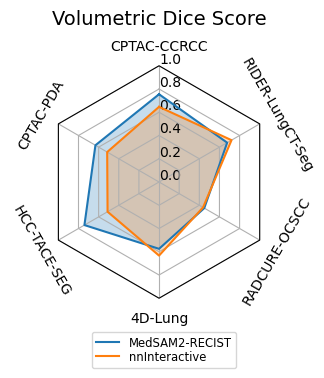

In [5]:
# Define the performance data for the validation sets (setup code taken from https://matplotlib.org/stable/gallery/specialty_plots/radar_chart.html)
# First array in the actual numbers section is MedSAM2-RECIST, second is nnInteractive
## Old order
# val_perf_data = [['TCIA_CPTAC-CCRCC', 'TCIA_CPTAC-PDA', 'TCIA_4D-Lung', 'TCIA_HCC-TACE-SEG', 'TCIA_RADCURE-OCSCC', 'TCIA_RIDER-LungCT-Seg'],
#                  ('Volumetric DICE', [[0.7547, 0.6319, 0.5749, 0.7411, 0.4492 , 0.6767], 
#                                        [0.6463, 0.5152, 0.633, 0.5113, 0.4372, 0.7197]]), 
#                 #  ('Hausdorff Distance', [[10.8325, 9.8183, 21.0853, 17.9978, 26.5912, 9.3284], 
#                 #                          [24.1832, 53.2325, 25.3684, 116.1303, 26.5481, 14.4828]])
#                                          ]
datasets = ['CPTAC-CCRCC', 'CPTAC-PDA', 'HCC-TACE-SEG', '4D-Lung', 'RADCURE-OCSCC', 'RIDER-LungCT-Seg']
ms2r_results = [0.7547, 0.6319, 0.7411, 0.5749, 0.4492 , 0.6767]
nnint_results = [0.6463, 0.5152, 0.5113, 0.633, 0.4372, 0.7197]
val_perf_data = [datasets,
                 ('Volumetric Dice Score', [ms2r_results, 
                                            nnint_results]), 
                #  ('Hausdorff Distance', [[10.8325, 9.8183, 17.9978, 21.0853, 26.5912, 9.3284], 
                #                          [24.1832, 53.2325, 116.1303, 25.3684, 26.5481, 14.4828]])
                                         ]
num_datasets = len(val_perf_data[0]) 
theta = radar_factory(num_datasets, frame = 'polygon') 

spoke_labels = val_perf_data.pop(0)
title, case_data = val_perf_data[0]

fig, ax = plt.subplots(figsize = (3, 3), subplot_kw = dict(projection = 'radar'))
fig.subplots_adjust(top = 0.85, bottom = 0.05) 

ax.set_rgrids([0, 0.2, 0.4, 0.6, 0.8, 1])
ax.set_title(title, position = (0.5, 1.3), pad = 30, ha = 'center', size = 14)

for d in case_data: 
    line = ax.plot(theta, d) 
    ax.fill(theta, d, alpha = 0.25, label = '_nolegend_')

ax.set_varlabels(spoke_labels) 
ax.set_rticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax.set_rlabel_position(0)

plt.gcf().canvas.draw()
angles = np.linspace(0,2*np.pi,len(ax.get_xticklabels())+1)
angles[np.cos(angles) < 0] = angles[np.cos(angles) < 0] + np.pi
angles = np.rad2deg(angles)
labels = []
for label, angle in zip(ax.get_xticklabels(), angles):
    x,y = label.get_position()
    lab = ax.text(x,y, label.get_text(), transform=label.get_transform(),
                  ha=label.get_ha(), va=label.get_va())
    lab.set_rotation(angle)
    labels.append(lab)
ax.set_xticklabels([])

labels = ('MedSAM2-RECIST', 'nnInteractive')
legend = ax.legend(labels, loc=(0.21, -0.30),
                   labelspacing=0.1, fontsize='small')
# fig, axes = plt.subplots(figsize = (9, 9), nrows = 1, ncols = 2, 
#                          subplot_kw=dict(projection='radar'))
# fig.subplots_adjust(wspace=0.25, hspace=0.20, top=0.85, bottom=0.05)

# colours = ['c', 'm']

# for ax, (title, case_data) in zip(axes.flat, val_perf_data): 
#     ax.set_rgrids([0.2, 0.4, 0.6, 0.8])
#     ax.set_title(title, weight='bold', size='medium', position=(0.5, 1.1),
#                     horizontalalignment='center', verticalalignment='center')
#     for d, colour in zip(case_data, colours):
#         ax.plot(theta, d, color=colour)
#         ax.fill(theta, d, facecolor=colour, alpha=0.25, label='_nolegend_')
#     ax.set_varlabels(spoke_labels)

# labels = ('MedSAM2-RECIST', 'nnInteractive')
# legend = axes[0].legend(labels, loc=(0.9, .95),
#                             labelspacing=0.1, fontsize='small')
plt.show()

In [6]:
def get_dataset(source):
    if "KiTS" in source: 
        dataset = "KiTS"
    elif "LIDC-IDRI" in source: 
        dataset = "LIDC-IDRI"
    elif "LNDb" in source: 
        dataset = "LNDb" 
    elif "MSD_colon" in source: 
        dataset = "MSD Colon"
    elif "MSD_hepaticvessel" in source: 
        dataset = "MSD Hepatic\nVessel" 
    elif "MSD_liver" in source: 
        dataset = "MSD Liver" 
    elif "MSD_lung" in source: 
        dataset = "MSD Lung"
    elif "MSD_pancreas" in source: 
        dataset = "MSD Pancreas"
    elif "NSCLC-Radiogenomics" in source: 
        dataset = "NSCLC-\nRadiogenomics" 
    else: 
        dataset = 'unknown'
    return dataset

In [7]:
abdomen_site = ['CPTAC-CCRCC', 'CPTAC-PDA', 'HCC-TACE-SEG', 'MSD Colon', 'MSD Hepatic\nVessel', 'MSD Liver', 'MSD Pancreas']
lung_site = ['4D-Lung', 'RIDER-\nLungCT-Seg', 'MSD Lung', 'NSCLC-\nRadiogenomics']
headneck_site = ['RADCURE-\nOCSCC']
def get_disease_site(dataset): 
    if dataset in abdomen_site: 
        return 'abdomen'
    elif dataset in lung_site: 
        return 'lung'
    elif dataset in headneck_site: 
        return 'head_neck'
    else: 
        return 'unknown'

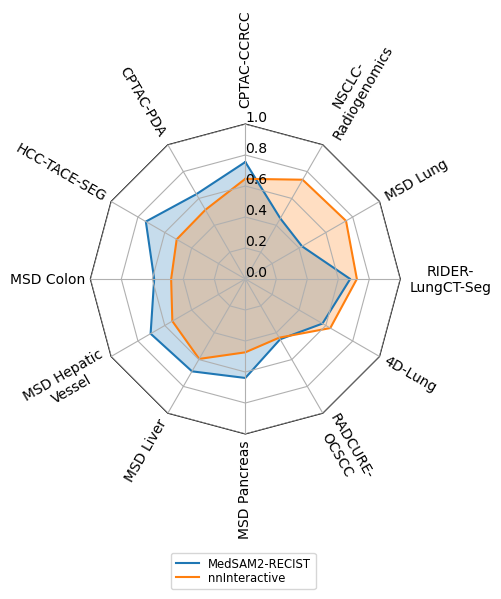

In [8]:
# Same radar plot, but instead now with the LesionLocator data in it as well 

# Load in the lesion locator baseline results for both models 
ms2r_ll_bl = pd.read_csv(dirs.RESULTS / "CCS_LL" / "ms2r_base_gt_pred_drop10voxvol.csv")
nnint_ll_bl = pd.read_csv(dirs.RESULTS / "CCS_LL" / "nnint_base_gt_pred_drop10voxvol.csv")

# Get the specific dataset from the source name 
ms2r_ll_bl['dataset_name'] = ms2r_ll_bl['source'].apply(get_dataset)
nnint_ll_bl['dataset_name'] = nnint_ll_bl['source'].apply(get_dataset)

# Subset by dataset and get the mean for each data source 
ms2r_means = [] 
nnint_means = [] 
dataset_order = []

dataset_to_skip = ['LNDb', 'LIDC-IDRI', 'KiTS'] # These are all dataset that nnInteractive was trained on, so potentially biased results
for dataset in ms2r_ll_bl['dataset_name'].unique(): 
    if dataset in dataset_to_skip: 
        continue
    dataset_order.append(dataset)
    ms2r_temp_set = ms2r_ll_bl[ms2r_ll_bl['dataset_name'] == dataset]
    nnint_temp_set = nnint_ll_bl[nnint_ll_bl['dataset_name'] == dataset]

    # Get means 
    ms2r_vol_dice_mean = ms2r_temp_set['volume_dice'].mean() 
    nnint_vol_dice_mean = nnint_temp_set['volume_dice'].mean()
    ms2r_means.append(ms2r_vol_dice_mean)
    nnint_means.append(nnint_vol_dice_mean) 

datasets_orig = ['CPTAC-CCRCC', 'CPTAC-PDA', 'HCC-TACE-SEG', '4D-Lung', 'RADCURE-\nOCSCC', 'RIDER-\nLungCT-Seg'] + dataset_order
ms2r_results_orig = [0.7547, 0.6319, 0.7411, 0.5749, 0.4492 , 0.6767] + ms2r_means
nnint_results_orig = [0.6463, 0.5152, 0.5113, 0.633, 0.4372, 0.7197] + nnint_means

# to get the datasets grouped by disease site (for really hitting home the site specific differences) 
results_dict = {'dataset': datasets_orig, 
                'MS2R_VolDice': ms2r_results_orig, 
                'nnint_VolDice': nnint_results_orig}
results_df = pd.DataFrame(results_dict) 

results_df['disease_site'] = results_df['dataset'].apply(get_disease_site) # Get the disease site based on dataset name

sorted_results = results_df.sort_values(by = 'disease_site') # Sort dataframe so all of the same disease site are adjacent to each other

datasets = sorted_results['dataset'].values.tolist() 
ms2r_results = sorted_results['MS2R_VolDice'].values.tolist() 
nnint_results = sorted_results['nnint_VolDice'].values.tolist()

val_perf_data = [datasets,
                 ('Volumetric Dice Score', [ms2r_results, 
                                            nnint_results]), 
                #  ('Hausdorff Distance', [[10.8325, 9.8183, 17.9978, 21.0853, 26.5912, 9.3284], 
                #                          [24.1832, 53.2325, 116.1303, 25.3684, 26.5481, 14.4828]])
                                         ]
num_datasets = len(val_perf_data[0]) 
theta = radar_factory(num_datasets, frame = 'polygon') 

spoke_labels = val_perf_data.pop(0)
title, case_data = val_perf_data[0]

fig, ax = plt.subplots(figsize = (4, 4), subplot_kw = dict(projection = 'radar'))
fig.subplots_adjust(top = 0.85, bottom = 0.05) 

ax.set_rgrids([0, 0.2, 0.4, 0.6, 0.8, 1])
# ax.set_title(title, position = (0.5, 2.5), pad = 70, ha = 'center', size = 14)

for d in case_data: 
    line = ax.plot(theta, d) 
    ax.fill(theta, d, alpha = 0.25, label = '_nolegend_')

ax.set_varlabels(spoke_labels) 
ax.set_rticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax.set_rlabel_position(0)

angles = np.linspace(0,2*np.pi,len(ax.get_xticklabels())+1)
angles = angles + np.pi/2
angles[np.cos(angles) < 0] = angles[np.cos(angles) < 0] + np.pi
angles = np.rad2deg(angles)

label_yoffsets = [0.3, 0.2, 0.25, 0.15, 0.2, 0.15, 0.23, 0.15, 0.1, 0.2, 0.15, 0.3]
labels = []
for label, angle, yoff in zip(ax.get_xticklabels(), angles, label_yoffsets):
    x,y = label.get_position()
    lab = ax.text(x,y-yoff, label.get_text(), transform=label.get_transform(),
                  ha=label.get_ha(), va=label.get_va())
    lab.set_rotation(angle)
    labels.append(lab)
ax.set_xticklabels([])
ax.set_axisbelow(False)
labels = ('MedSAM2-RECIST', 'nnInteractive')
legend = ax.legend(labels, loc=(0.26, -0.5),
                   labelspacing=0.1, fontsize='small')

plt.show()

# Lesion Locator metadata 

In [9]:
# Get image and mask counts for lesion locator datasets 
aaura_bl_df = pd.read_csv('/home/bhkuser/bhklab/kaitlyn/recist-vs-reality/data/CCS_LL/aaura_Baseline_index.csv')
aaura_bl_df['dataset_name'] = aaura_bl_df['source'].apply(get_dataset)

msd_col_df = aaura_bl_df[aaura_bl_df['dataset_name'] == 'MSD Colon']
msd_col_img = msd_col_df['image_path'].nunique()
msd_col_mask = msd_col_df['mask_path'].nunique()

msd_hv_df = msd_col_df = aaura_bl_df[aaura_bl_df['dataset_name'] == 'MSD Hepatic\nVessel']
msd_hv_img = msd_hv_df['image_path'].nunique()
msd_hv_mask = msd_hv_df['mask_path'].nunique()

msd_liv_df = msd_col_df = aaura_bl_df[aaura_bl_df['dataset_name'] == 'MSD Liver']
msd_liv_img = msd_liv_df['image_path'].nunique()
msd_liv_mask = msd_liv_df['mask_path'].nunique()

msd_pan_df = msd_col_df = aaura_bl_df[aaura_bl_df['dataset_name'] == 'MSD Pancreas']
msd_pan_img = msd_pan_df['image_path'].nunique()
msd_pan_mask = msd_pan_df['mask_path'].nunique()

msd_lung_df = msd_col_df = aaura_bl_df[aaura_bl_df['dataset_name'] == 'MSD Lung']
msd_lung_img = msd_lung_df['image_path'].nunique()
msd_lung_mask = msd_lung_df['mask_path'].nunique()

nsclc_df = msd_col_df = aaura_bl_df[aaura_bl_df['dataset_name'] == 'NSCLC-\nRadiogenomics']
nsclc_img = nsclc_df['image_path'].nunique()
nsclc_mask = nsclc_df['mask_path'].nunique()

In [ ]:
nsclc_mask

# Heat Map

In [ ]:
# Heatmap visualization 

recist_cats = sorted(['CR', 'PR', 'SD', 'PD'])

def get_percs(conf_mat_df,
              recist_categories: list): 
    """Confusion matrix must have labels matching with the RECIST categories"""
    recist_percents = []
    for cat in recist_categories: 
        curr_subset = conf_mat_df.loc[cat]
        curr_percs = ["{:.2%}".format(value) for value in curr_subset/np.sum(curr_subset)]
        recist_percents.append(curr_percs)

    recist_perc_arr = np.array(recist_percents) 
    recist_perc_arr = recist_perc_arr.flatten() 

    return recist_perc_arr

# Drop any NaNs from the table 
ms2r_recist_drop_df = ms2r_recist_df.dropna()
# For MedSAM2-RECIST 
ms2r_confmat = confusion_matrix(ms2r_recist_drop_df['GT_RECIST_cat'], ms2r_recist_drop_df['PRED_RECIST_cat'])
print(ms2r_confmat)
ms2r_confmat_df = pd.DataFrame(ms2r_confmat, index = recist_cats, columns = recist_cats)
ms2r_counts = ["{0:0.0f}".format(value) for value in ms2r_confmat.flatten()]
ms2r_percents = get_percs(ms2r_confmat_df, recist_cats) 
labels = [f"{counts}\n{percs}" for counts, percs in zip(ms2r_counts, ms2r_percents)] 
labels = np.asarray(labels).reshape(4,4)

ms2r_heatmap = sns.heatmap(ms2r_confmat_df, annot = labels, fmt='', cmap='Blues')
ms2r_heatmap.set_xlabel('Predicted Category')
ms2r_heatmap.set_ylabel('Ground Truth Category')
ms2r_heatmap.set_title('MedSAM2-RECIST')
plt.show()

recist_cats = sorted(['PD', 'SD', 'PR'])
# For nnInteractive 
nnint_confmat = confusion_matrix(nnint_recist_df['GT_RECIST_cat'], nnint_recist_df['PRED_RECIST_cat'])
print(nnint_confmat)
nnint_confmat_df = pd.DataFrame(nnint_confmat, index = recist_cats, columns = recist_cats)
nnint_counts = ["{0:0.0f}".format(value) for value in nnint_confmat.flatten()]
nnint_percents = get_percs(nnint_confmat_df, recist_cats) 
labels = [f"{counts}\n{percs}" for counts, percs in zip(nnint_counts, nnint_percents)] 
labels = np.asarray(labels).reshape(3,3)

nnint_heatmap = sns.heatmap(nnint_confmat_df, annot = labels, fmt='', cmap='Blues')
nnint_heatmap.set_xlabel('Predicted Category')
nnint_heatmap.set_ylabel('Ground Truth Category')
nnint_heatmap.set_title('nnInteractive')
plt.show()

# Hexbin Plots

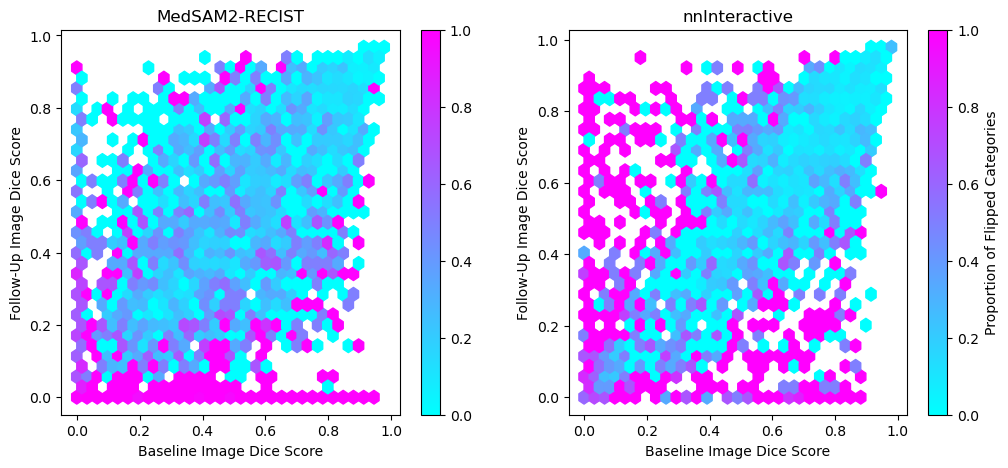

In [10]:
# Hexbin plot assessment 

fig, axes = plt.subplots(figsize = (12,5), nrows = 1, ncols = 2)
# For MedSAM2-RECIST 
ms2r_hb = axes[0].hexbin(ms2r_recist_df['t1_DICE'], ms2r_recist_df['t2_DICE'], C=ms2r_recist_df['RECIST_flip'], 
                         reduce_C_function=np.mean, gridsize = 30, cmap = 'cool')
axes[0].set_title("MedSAM2-RECIST")
axes[0].set_xlabel("Baseline Image Dice Score") 
axes[0].set_ylabel("Follow-Up Image Dice Score")
nnint_hb = axes[1].hexbin(nnint_recist_df['t1_DICE'], nnint_recist_df['t2_DICE'], C=nnint_recist_df['RECIST_flip'], 
                         reduce_C_function=np.mean, gridsize=30, cmap='cool')
axes[1].set_title("nnInteractive")
axes[1].set_xlabel("Baseline Image Dice Score") 
axes[1].set_ylabel("Follow-Up Image Dice Score")
cb = fig.colorbar(ms2r_hb, ax = axes[0])
cb = fig.colorbar(nnint_hb, ax = axes[1])
cb.set_label("Proportion of Flipped Categories") 

In [ ]:
# Make same hexplot but for 2D Dice instead 
fig, axes = plt.subplots(figsize = (12,5), nrows = 1, ncols = 2)
# For MedSAM2-RECIST 
ms2r_hb = axes[0].hexbin(ms2r_recist_df['t1_2D_DICE'], ms2r_recist_df['t2_2D_DICE'], C=ms2r_recist_df['RECIST_flip'], 
                         reduce_C_function=np.mean, gridsize = 30, cmap = 'cool')
axes[0].set_title("MedSAM2-RECIST")
axes[0].set_xlabel("Baseline Image 2D Dice Score") 
axes[0].set_ylabel("Follow-Up Image 2D Dice Score")
nnint_hb = axes[1].hexbin(nnint_recist_df['t1_2D_DICE'], nnint_recist_df['t2_2D_DICE'], C=nnint_recist_df['RECIST_flip'], 
                         reduce_C_function=np.mean, gridsize=30, cmap='cool')
axes[1].set_title("nnInteractive")
axes[1].set_xlabel("Baseline Image 2D Dice Score") 
axes[1].set_ylabel("Follow-Up Image 2D Dice Score")
cb = fig.colorbar(ms2r_hb, ax = axes[0])
cb = fig.colorbar(nnint_hb, ax = axes[1])
cb.set_label("Proportion of Flipped Categories") 

## Updated Hexbins from lab meeting February 10, 2026

### Adding alpha for number of samples in each hexbin

In [ ]:
fig, axes = plt.subplots(figsize = (12,5), nrows = 1, ncols = 2)
# For MedSAM2-RECIST 
ms2r_hb = axes[0].hexbin(ms2r_recist_df['t1_DICE'], ms2r_recist_df['t2_DICE'], C=ms2r_recist_df['RECIST_flip'], 
                         reduce_C_function=np.mean, gridsize = 30, cmap = 'cool')
axes[0].set_title("MedSAM2-RECIST")
axes[0].set_xlabel("Baseline Image Dice Score") 
axes[0].set_ylabel("Follow-Up Image Dice Score")

# For nnInteractive
nnint_hb = axes[1].hexbin(nnint_recist_df['t1_DICE'], nnint_recist_df['t2_DICE'], C=nnint_recist_df['RECIST_flip'], 
                         reduce_C_function=np.mean, gridsize=30, cmap='cool')
axes[1].set_title("nnInteractive")
axes[1].set_xlabel("Baseline Image Dice Score") 
axes[1].set_ylabel("Follow-Up Image Dice Score")
cb = fig.colorbar(ms2r_hb, ax = axes[0])
cb = fig.colorbar(nnint_hb, ax = axes[1])
cb.set_label("Proportion of Flipped Categories") 

In [ ]:
print("help")

# Scatter Plots

In [ ]:
# Volume comparisons 
fig, axes = plt.subplots(2, 2, figsize = (8, 8))
fig.suptitle('MedSAM2-RECIST') 
axes[0, 0].scatter(ms2r_recist_df['GT_t1_vox_vol'], ms2r_recist_df['PRED_t1_vox_vol'], alpha = 0.2)
axes[0, 0].set_xlabel('Baseline Ground Truth Voxel Volume') 
axes[0, 0].set_ylabel('Baseline Predicted Voxel Volume')
axes[0, 1].scatter(ms2r_recist_df['GT_t2_vox_vol'], ms2r_recist_df['PRED_t2_vox_vol'], alpha = 0.2)
axes[0, 1].set_xlabel('Follow-Up Ground Truth Voxel Volume') 
axes[0, 1].set_ylabel('Follow-Up Predicted Voxel Volume')
axes[1, 0].scatter(ms2r_recist_df['GT_t1_vox_vol'], ms2r_recist_df['t1_DICE'], alpha = 0.2)
axes[1, 0].set_xlabel('Baseline Ground Truth Voxel Volume') 
axes[1, 0].set_ylabel('Baseline Volumetric Dice')
axes[1, 1].scatter(ms2r_recist_df['GT_t2_vox_vol'], ms2r_recist_df['t2_DICE'], alpha = 0.2)
axes[1, 1].set_xlabel('Follow-Up Ground Truth Voxel Volume')
axes[1, 1].set_ylabel('Follow-Up Volumetric Dice')
fig.tight_layout()

fig, axes = plt.subplots(2, 2, figsize = (8, 8))
fig.suptitle('nnInteractive') 
axes[0, 0].scatter(nnint_recist_df['GT_t1_vox_vol'], nnint_recist_df['PRED_t1_vox_vol'], alpha = 0.2, c = 'm')
axes[0, 0].set_xlabel('Baseline Ground Truth Voxel Volume') 
axes[0, 0].set_ylabel('Baseline Predicted Voxel Volume')
axes[0, 1].scatter(nnint_recist_df['GT_t2_vox_vol'], nnint_recist_df['PRED_t2_vox_vol'], alpha = 0.2, c = 'm')
axes[0, 1].set_xlabel('Follow-Up Ground Truth Voxel Volume') 
axes[0, 1].set_ylabel('Follow-Up Predicted Voxel Volume')
axes[1, 0].scatter(nnint_recist_df['GT_t1_vox_vol'], nnint_recist_df['t1_DICE'], alpha = 0.2, c = 'm')
axes[1, 0].set_xlabel('Baseline Ground Truth Voxel Volume') 
axes[1, 0].set_ylabel('Baseline Volumetric Dice')
axes[1, 1].scatter(nnint_recist_df['GT_t2_vox_vol'], nnint_recist_df['t2_DICE'], alpha = 0.2, c = 'm')
axes[1, 1].set_xlabel('Follow-Up Ground Truth Voxel Volume')
axes[1, 1].set_ylabel('Follow-Up Volumetric Dice')
fig.tight_layout()

In [ ]:
def get_merge_data(mask_path): 
	""" 
	Used in order to get a common column to merge on based on the mask paths of t1 and t2 masks 

	Parameters
	----------
	mask_path: str
		The path to the current mask in question 
	
	Returns
	----------
	merge_data: str 
		The string that will be used to merge the two aligned dataframes on 
	"""
	merge_data = "/".join(mask_path.split("/")[-2:])

	return merge_data 

In [ ]:
# Volume comparisons on log-log scale 

# Also going to merge in the datasets and disease site information from the aaura index for both 
aaura_idx = pd.read_csv("/home/bhkuser/bhklab/kaitlyn/recist-vs-reality/data/CCS_LL/aaura_Baseline_index.csv")
ms2r_recist_df['merge_col'] = ms2r_recist_df['GT_t1_mask_path'].apply(get_merge_data) 
aaura_idx['merge_col'] = aaura_idx['mask_path'].apply(get_merge_data)
aaura_idx_sub = aaura_idx[['lesion_location', 'source', 'merge_col']]
ms2r_recist_aaura_df = pd.merge(ms2r_recist_df, aaura_idx_sub, on = 'merge_col', how = 'inner')

nnint_recist_df['merge_col'] = nnint_recist_df['GT_t1_mask_path'].apply(get_merge_data) 
nnint_recist_aaura_df = pd.merge(nnint_recist_df, aaura_idx_sub, on = 'merge_col', how = 'inner')

## Label colouring 
loc_map = {} 
i = 0
for cat in aaura_idx['lesion_location'].unique(): 
    loc_map[cat] = i 
    i += 1
loc_colours_ms2r = ms2r_recist_aaura_df['lesion_location'].map(loc_map)

source_map = {} 
i = 0
for cat in aaura_idx['source'].unique():
    source_map[cat] = i 
    i += 1
source_colours_ms2r = ms2r_recist_aaura_df['source'].map(source_map)

locs = ['abdomen', 'lung'] 
loc_colours = mcolors.ListedColormap(['green', 'magenta']) 

loc_leg_hand = []
for loc, colour, in zip(locs, ['green', 'magenta']): 
    patch = mpatches.Patch(color=colour, label = loc) 
    loc_leg_hand.append(patch)

fig, axes = plt.subplots(2, 2, figsize = (8, 8))
fig.suptitle('MedSAM2-RECIST') 
ax1 = axes[0, 0].scatter(ms2r_recist_aaura_df['GT_t1_vox_vol'], ms2r_recist_aaura_df['PRED_t1_vox_vol'], alpha = 0.5, c=loc_colours_ms2r, cmap=loc_colours)
axes[0, 0].set_xlabel('Baseline Ground Truth Voxel Volume') 
axes[0, 0].set_ylabel('Baseline Predicted Voxel Volume')
axes[0, 0].set_xscale('log') 
axes[0, 0].set_yscale('log')
# axes[0, 0].legend(handles = loc_leg_hand, loc='upper left', title='Lesion Location')

ax2 = axes[0, 1].scatter(ms2r_recist_aaura_df['GT_t2_vox_vol'], ms2r_recist_aaura_df['PRED_t2_vox_vol'], alpha = 0.5, c=loc_colours_ms2r, cmap=loc_colours)
axes[0, 1].set_xlabel('Follow-Up Ground Truth Voxel Volume') 
axes[0, 1].set_ylabel('Follow-Up Predicted Voxel Volume')
axes[0, 1].set_xscale('log') 
axes[0, 1].set_yscale('log')
# axes[0, 1].legend(handles = loc_leg_hand, loc='upper left', title='Lesion Location')

ax3 = axes[1, 0].scatter(ms2r_recist_aaura_df['GT_t1_vox_vol'], ms2r_recist_aaura_df['t1_DICE'], alpha = 0.5, c=loc_colours_ms2r, cmap=loc_colours)
axes[1, 0].set_xlabel('Baseline Ground Truth Voxel Volume') 
axes[1, 0].set_ylabel('Baseline Volumetric Dice')
axes[1, 0].set_xscale('log') 
# axes[1, 0].set_yscale('log')
# axes[1, 0].legend(handles = loc_leg_hand, loc='lower right', title='Lesion Location')

ax4 = axes[1, 1].scatter(ms2r_recist_aaura_df['GT_t2_vox_vol'], ms2r_recist_aaura_df['t2_DICE'], alpha = 0.5, c=loc_colours_ms2r, cmap=loc_colours)
axes[1, 1].set_xlabel('Follow-Up Ground Truth Voxel Volume')
axes[1, 1].set_ylabel('Follow-Up Volumetric Dice')
axes[1, 1].set_xscale('log') 
# axes[1, 1].set_yscale('log')
# axes[1, 1].legend(handles = loc_leg_hand, loc='lower right', title='Lesion Location')

fig.tight_layout()
fig.legend(handles = loc_leg_hand, loc='center right', bbox_to_anchor=(1.15, 0.5), title='Lesion Location')

fig, axes = plt.subplots(2, 2, figsize = (8, 8))
fig.suptitle('nnInteractive') 
ax1 = axes[0, 0].scatter(nnint_recist_df['GT_t1_vox_vol'], nnint_recist_df['PRED_t1_vox_vol'], alpha = 0.5, c=loc_colours_ms2r, cmap=loc_colours)
axes[0, 0].set_xlabel('Baseline Ground Truth Voxel Volume') 
axes[0, 0].set_ylabel('Baseline Predicted Voxel Volume')
axes[0, 0].set_xscale('log') 
axes[0, 0].set_yscale('log')
# axes[0, 0].legend(handles = loc_leg_hand, loc='lower right', title='Lesion Location')

ax2 = axes[0, 1].scatter(nnint_recist_df['GT_t2_vox_vol'], nnint_recist_df['PRED_t2_vox_vol'], alpha = 0.5, c=loc_colours_ms2r, cmap=loc_colours)
axes[0, 1].set_xlabel('Follow-Up Ground Truth Voxel Volume') 
axes[0, 1].set_ylabel('Follow-Up Predicted Voxel Volume')
axes[0, 1].set_xscale('log') 
axes[0, 1].set_yscale('log')
# axes[0, 1].legend(handles = loc_leg_hand, loc='lower right', title='Lesion Location')

ax3 = axes[1, 0].scatter(nnint_recist_df['GT_t1_vox_vol'], nnint_recist_df['t1_DICE'], alpha = 0.5, c=loc_colours_ms2r, cmap=loc_colours)
axes[1, 0].set_xlabel('Baseline Ground Truth Voxel Volume') 
axes[1, 0].set_ylabel('Baseline Volumetric Dice')
axes[1, 0].set_xscale('log') 
# axes[1, 0].set_yscale('log')
# axes[1, 0].legend(handles = loc_leg_hand, loc='lower right', title='Lesion Location')

ax4 = axes[1, 1].scatter(nnint_recist_df['GT_t2_vox_vol'], nnint_recist_df['t2_DICE'], alpha = 0.5, c=loc_colours_ms2r, cmap=loc_colours)
axes[1, 1].set_xlabel('Follow-Up Ground Truth Voxel Volume')
axes[1, 1].set_ylabel('Follow-Up Volumetric Dice')
axes[1, 1].set_xscale('log') 
# axes[1, 1].set_yscale('log')
# axes[1, 1].legend(handles = loc_leg_hand, loc='lower right', title='Lesion Location')

fig.tight_layout()
fig.legend(handles = loc_leg_hand, loc='center right', bbox_to_anchor=(1.15, 0.5), title='Lesion Location')

In [ ]:
def get_dataset(source):
    if "KiTS" in source: 
        dataset = "KiTS"
    elif "LIDC-IDRI" in source: 
        dataset = "LIDC-IDRI"
    elif "LNDb" in source: 
        dataset = "LNDb" 
    elif "MSD_colon" in source: 
        dataset = "MSD_colon"
    elif "MSD_hepaticvessel" in source: 
        dataset = "MSD_hepaticvessel" 
    elif "MSD_liver" in source: 
        dataset = "MSD_liver" 
    elif "MSD_lung" in source: 
        dataset = "MSD_lung"
    elif "MSD_pancreas" in source: 
        dataset = "MSD_pancreas"
    elif "NSCLC-Radiogenomics" in source: 
        dataset = "NSCLC-Radiogenomics" 
    else: 
        dataset = 'unknown'
    return dataset

In [ ]:
# Volume comparisons on log-log scale 

# Also going to merge in the datasets and disease site information from the aaura index for both 
aaura_idx = pd.read_csv("/home/bhkuser/bhklab/kaitlyn/recist-vs-reality/data/CCS_LL/aaura_Baseline_index.csv")
ms2r_recist_df['merge_col'] = ms2r_recist_df['GT_t1_mask_path'].apply(get_merge_data) 
aaura_idx['merge_col'] = aaura_idx['mask_path'].apply(get_merge_data)
aaura_idx['dataset_name'] = aaura_idx['source'].apply(get_dataset)
aaura_idx_sub = aaura_idx[['lesion_location', 'source', 'dataset_name', 'merge_col']]
ms2r_recist_aaura_df = pd.merge(ms2r_recist_df, aaura_idx_sub, on = 'merge_col', how = 'inner')

nnint_recist_df['merge_col'] = nnint_recist_df['GT_t1_mask_path'].apply(get_merge_data) 
nnint_recist_aaura_df = pd.merge(nnint_recist_df, aaura_idx_sub, on = 'merge_col', how = 'inner')

## Label colouring 
loc_map = {} 
i = 0
for cat in aaura_idx['lesion_location'].unique(): 
    loc_map[cat] = i 
    i += 1
loc_colours_ms2r = ms2r_recist_aaura_df['lesion_location'].map(loc_map)

source_map = {} 
i = 0
for cat in aaura_idx['dataset_name'].unique():
    source_map[cat] = i 
    i += 1
source_colours_ms2r = ms2r_recist_aaura_df['dataset_name'].map(source_map)

sources = aaura_idx['dataset_name'].unique()
source_colours = mcolors.ListedColormap(['green', 'aquamarine', 'blue', 'deeppink', 'red', 'royalblue', 'purple', 'gold', 'firebrick']) 

loc_leg_hand = []
for loc, colour, in zip(sources, ['green', 'aquamarine', 'blue', 'deeppink', 'red', 'royalblue', 'purple', 'gold', 'firebrick']): 
    patch = mpatches.Patch(color=colour, label = loc) 
    loc_leg_hand.append(patch)

fig, axes = plt.subplots(2, 2, figsize = (8, 8))
fig.suptitle('MedSAM2-RECIST') 
ax1 = axes[0, 0].scatter(ms2r_recist_aaura_df['GT_t1_vox_vol'], ms2r_recist_aaura_df['PRED_t1_vox_vol'], alpha = 0.5, c=source_colours_ms2r, cmap=source_colours)
axes[0, 0].set_xlabel('Baseline Ground Truth Voxel Volume') 
axes[0, 0].set_ylabel('Baseline Predicted Voxel Volume')
axes[0, 0].set_xscale('log') 
axes[0, 0].set_yscale('log')
# axes[0, 0].legend(handles = loc_leg_hand, loc='upper left', title='Lesion Location')

ax2 = axes[0, 1].scatter(ms2r_recist_aaura_df['GT_t2_vox_vol'], ms2r_recist_aaura_df['PRED_t2_vox_vol'], alpha = 0.5, c=source_colours_ms2r, cmap=source_colours)
axes[0, 1].set_xlabel('Follow-Up Ground Truth Voxel Volume') 
axes[0, 1].set_ylabel('Follow-Up Predicted Voxel Volume')
axes[0, 1].set_xscale('log') 
axes[0, 1].set_yscale('log')
# axes[0, 1].legend(handles = loc_leg_hand, loc='upper left', title='Lesion Location')

ax3 = axes[1, 0].scatter(ms2r_recist_aaura_df['GT_t1_vox_vol'], ms2r_recist_aaura_df['t1_DICE'], alpha = 0.5, c=source_colours_ms2r, cmap=source_colours)
axes[1, 0].set_xlabel('Baseline Ground Truth Voxel Volume') 
axes[1, 0].set_ylabel('Baseline Volumetric Dice')
axes[1, 0].set_xscale('log') 
# axes[1, 0].set_yscale('log')
# axes[1, 0].legend(handles = loc_leg_hand, loc='lower right', title='Lesion Location')

ax4 = axes[1, 1].scatter(ms2r_recist_aaura_df['GT_t2_vox_vol'], ms2r_recist_aaura_df['t2_DICE'], alpha = 0.5, c=source_colours_ms2r, cmap=source_colours)
axes[1, 1].set_xlabel('Follow-Up Ground Truth Voxel Volume')
axes[1, 1].set_ylabel('Follow-Up Volumetric Dice')
axes[1, 1].set_xscale('log') 
# axes[1, 1].set_yscale('log')
# axes[1, 1].legend(handles = loc_leg_hand, loc='lower right', title='Lesion Location')

fig.tight_layout()
fig.legend(handles = loc_leg_hand, loc='center right', bbox_to_anchor=(1.3, 0.5), title='Dataset')

fig, axes = plt.subplots(2, 2, figsize = (8, 8))
fig.suptitle('nnInteractive') 
ax1 = axes[0, 0].scatter(nnint_recist_df['GT_t1_vox_vol'], nnint_recist_df['PRED_t1_vox_vol'], alpha = 0.5, c=source_colours_ms2r, cmap=source_colours)
axes[0, 0].set_xlabel('Baseline Ground Truth Voxel Volume') 
axes[0, 0].set_ylabel('Baseline Predicted Voxel Volume')
axes[0, 0].set_xscale('log') 
axes[0, 0].set_yscale('log')
# axes[0, 0].legend(handles = loc_leg_hand, loc='lower right', title='Lesion Location')

ax2 = axes[0, 1].scatter(nnint_recist_df['GT_t2_vox_vol'], nnint_recist_df['PRED_t2_vox_vol'], alpha = 0.5, c=source_colours_ms2r, cmap=source_colours)
axes[0, 1].set_xlabel('Follow-Up Ground Truth Voxel Volume') 
axes[0, 1].set_ylabel('Follow-Up Predicted Voxel Volume')
axes[0, 1].set_xscale('log') 
axes[0, 1].set_yscale('log')
# axes[0, 1].legend(handles = loc_leg_hand, loc='lower right', title='Lesion Location')

ax3 = axes[1, 0].scatter(nnint_recist_df['GT_t1_vox_vol'], nnint_recist_df['t1_DICE'], alpha = 0.5, c=source_colours_ms2r, cmap=source_colours)
axes[1, 0].set_xlabel('Baseline Ground Truth Voxel Volume') 
axes[1, 0].set_ylabel('Baseline Volumetric Dice')
axes[1, 0].set_xscale('log') 
# axes[1, 0].set_yscale('log')
# axes[1, 0].legend(handles = loc_leg_hand, loc='lower right', title='Lesion Location')

ax4 = axes[1, 1].scatter(nnint_recist_df['GT_t2_vox_vol'], nnint_recist_df['t2_DICE'], alpha = 0.5, c=source_colours_ms2r, cmap=source_colours)
axes[1, 1].set_xlabel('Follow-Up Ground Truth Voxel Volume')
axes[1, 1].set_ylabel('Follow-Up Volumetric Dice')
axes[1, 1].set_xscale('log') 
# axes[1, 1].set_yscale('log')
# axes[1, 1].legend(handles = loc_leg_hand, loc='lower right', title='Lesion Location')

fig.tight_layout()
fig.legend(handles = loc_leg_hand, loc='center right', bbox_to_anchor=(1.3, 0.5), title='Dataset')

In [ ]:
def get_bbox(mask): 
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    ymin, ymax = np.where(rows)[0][[0, -1]]
    xmin, xmax = np.where(cols)[0][[0, -1]]

    width = xmax - xmin
    height = ymax - ymin

    return (xmin, ymin), width, height

In [ ]:
# Bounding box examples 

# Load in npzs 
ccrcc_npz = np.load(dirs.RESULTS / "CCS_LL/C3N-01651_0055_RTSTRUCT_348225.npz")
ccrcc_img = ccrcc_npz['imgs'] 
ccrcc_gts = ccrcc_npz['gts']
ccrcc_pred = ccrcc_npz['preds'] 
ccrcc_midslice = 109

pda_npz = np.load(dirs.RESULTS / "CCS_LL/C3L-04495_0043_RTSTRUCT_413631.npz")
pda_img = pda_npz['imgs'] 
pda_gts = pda_npz['gts']
pda_pred = pda_npz['preds']
pda_midslice = 4

lung_npz = np.load(dirs.RESULTS / "CCS_LL/R01-012_0005_SEG_52169379.npz")
lung_img = lung_npz['imgs']
lung_gts = lung_npz['gts'] 
lung_pred = lung_npz['preds']
lung_midslice = 292

# Get bounding boxes for all examples 
ccrcc_min_pt_gts, ccrcc_w_gts, ccrcc_h_gts = get_bbox(ccrcc_gts[ccrcc_midslice]) 
ccrcc_min_pt_pred, ccrcc_w_pred, ccrcc_h_pred = get_bbox(ccrcc_pred[ccrcc_midslice]) 
ccrcc_rect_gts = mpatches.Rectangle(ccrcc_min_pt_gts, ccrcc_w_gts, ccrcc_h_gts, linewidth=1, edgecolor='c', facecolor='none', label="Ground Truth")
ccrcc_rect_pred = mpatches.Rectangle(ccrcc_min_pt_pred, ccrcc_w_pred, ccrcc_h_pred, linewidth=1, edgecolor='m', facecolor='none', label="Prediction")

pda_min_pt_gts, pda_w_gts, pda_h_gts = get_bbox(pda_gts[pda_midslice]) 
pda_min_pt_pred, pda_w_pred, pda_h_pred = get_bbox(pda_pred[pda_midslice])
pda_rect_gts = mpatches.Rectangle(pda_min_pt_gts, pda_w_gts, pda_h_gts, linewidth=1, edgecolor='c', facecolor='none')
pda_rect_pred = mpatches.Rectangle(pda_min_pt_pred, pda_w_pred, pda_h_pred, linewidth=1, edgecolor='m', facecolor='none')

lung_min_pt_gts, lung_w_gts, lung_h_gts = get_bbox(lung_gts[lung_midslice]) 
lung_min_pt_pred, lung_w_pred, lung_h_pred = get_bbox(lung_pred[lung_midslice])
lung_rect_gts = mpatches.Rectangle(lung_min_pt_gts, lung_w_gts, lung_h_gts, linewidth=1, edgecolor='c', facecolor='none')
lung_rect_pred = mpatches.Rectangle(lung_min_pt_pred, lung_w_pred, lung_h_pred, linewidth=1, edgecolor='m', facecolor='none')

# Plot all examples in subplots 
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

axes[0].imshow(np.clip(ccrcc_img[ccrcc_midslice], -160, 240), cmap = "gray") 
axes[0].add_patch(ccrcc_rect_gts) 
axes[0].add_patch(ccrcc_rect_pred)
axes[0].axis("off") 
axes[0].set_title("CCRCC") 

axes[1].imshow(np.clip(pda_img[pda_midslice], -160, 240), cmap = "gray") 
axes[1].add_artist(pda_rect_gts) 
axes[1].add_artist(pda_rect_pred)
axes[1].axis("off") 
axes[1].set_title("PDA")

axes[2].imshow(np.clip(lung_img[lung_midslice], -1350, 150), cmap = "gray") 
axes[2].add_artist(lung_rect_gts) 
axes[2].add_artist(lung_rect_pred)
axes[2].axis("off") 
axes[2].set_title("NSCLC")

fig.legend(handles=[ccrcc_rect_gts, ccrcc_rect_pred], loc='lower center', ncol=2, bbox_to_anchor = (0.5, 0.1))
plt.tight_layout()